In [31]:
import numpy as np 
import pandas as pd 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [32]:
!pip install pandas==2.3.3

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

churn = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f'telco_customer_churn: {churn.shape[0]:>7,} rows  x  {churn.shape[1]:>3} columns')

telco_customer_churn:   7,043 rows  x   21 columns


**Target**
The “Churn” column is our target.

In [34]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [35]:
# EMPTY STRINGS
for col in churn.columns:
    empty_count = (churn[col].astype(str).str.strip() == '').sum()
    if empty_count > 0:
        print(f"{col}: {empty_count} empty strings")
        

TotalCharges: 11 empty strings


In [36]:
# NaN values
missing = churn.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No NaN values found")

No NaN values found


In [37]:
# Check for Zeros
for col in churn.columns:
    zero_count = (churn[col] == 0).sum()
    if zero_count > 0:
        print(f"{col}: {zero_count} zeros")

SeniorCitizen: 5901 zeros
tenure: 11 zeros


It seems the only values were Total Charges as in does those empty strings mean if the person had no subscription or did they pay 0 for their subscription? 

In [38]:
mask = churn['TotalCharges'].str.strip() == ''
cols = ['customerID', 'tenure', 'PhoneService', 'InternetService', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn']
print(churn.loc[mask, cols])

      customerID  tenure PhoneService InternetService  Contract  \
488   4472-LVYGI       0           No             DSL  Two year   
753   3115-CZMZD       0          Yes              No  Two year   
936   5709-LVOEQ       0          Yes             DSL  Two year   
1082  4367-NUYAO       0          Yes              No  Two year   
1340  1371-DWPAZ       0           No             DSL  Two year   
3331  7644-OMVMY       0          Yes              No  Two year   
3826  3213-VVOLG       0          Yes              No  Two year   
4380  2520-SGTTA       0          Yes              No  Two year   
5218  2923-ARZLG       0          Yes              No  One year   
6670  4075-WKNIU       0          Yes             DSL  Two year   
6754  2775-SEFEE       0          Yes             DSL  Two year   

      MonthlyCharges TotalCharges Churn  
488            52.55                 No  
753            20.25                 No  
936            80.85                 No  
1082           25.75       

This means the people were subscribed but didn't pay yet so 0 is appropriate to add.

In [39]:
churn['TotalCharges'] = churn['TotalCharges'].replace(' ', '0')
cols = ['customerID', 'tenure', 'PhoneService', 'InternetService', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn']
print(churn.loc[mask, cols])

      customerID  tenure PhoneService InternetService  Contract  \
488   4472-LVYGI       0           No             DSL  Two year   
753   3115-CZMZD       0          Yes              No  Two year   
936   5709-LVOEQ       0          Yes             DSL  Two year   
1082  4367-NUYAO       0          Yes              No  Two year   
1340  1371-DWPAZ       0           No             DSL  Two year   
3331  7644-OMVMY       0          Yes              No  Two year   
3826  3213-VVOLG       0          Yes              No  Two year   
4380  2520-SGTTA       0          Yes              No  Two year   
5218  2923-ARZLG       0          Yes              No  One year   
6670  4075-WKNIU       0          Yes             DSL  Two year   
6754  2775-SEFEE       0          Yes             DSL  Two year   

      MonthlyCharges TotalCharges Churn  
488            52.55            0    No  
753            20.25            0    No  
936            80.85            0    No  
1082           25.75       

In [40]:
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'])
print(churn['TotalCharges'].dtype)

float64


In [42]:
churn.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


1. Churn has more "No" than "Yes" (top = No, freq = 5174) so its unbalanced.
2. Contract skews toward Month-to-month (freq = 3875)
3. PhoneService is heavily skewed, freq = 6361 have phone service
4. gender and Partner are close to 50/50. These are likely weak predictors on their own
5. 

Columns like TechSupport have 3 categories: Yes, No, No internet service. 
The third category only makes sense for customers who have InternetService == 'No'. 
So the set of customers with 'No internet service' in each of those 6 columns should be exactly the same set of customers, and should match InternetService == 'No'.

In [44]:
addon_cols = ['TechSupport', 'StreamingTV', 'StreamingMovies']

no_internet = (churn['InternetService'] == 'No').sum()
print('Customers with InternetService == No:', no_internet)

for col in addon_cols:
    count = (churn[col] == 'No internet service').sum()
    print(f'{col} == "No internet service": {count}')

Customers with InternetService == No: 1526
TechSupport == "No internet service": 1526
StreamingTV == "No internet service": 1526
StreamingMovies == "No internet service": 1526


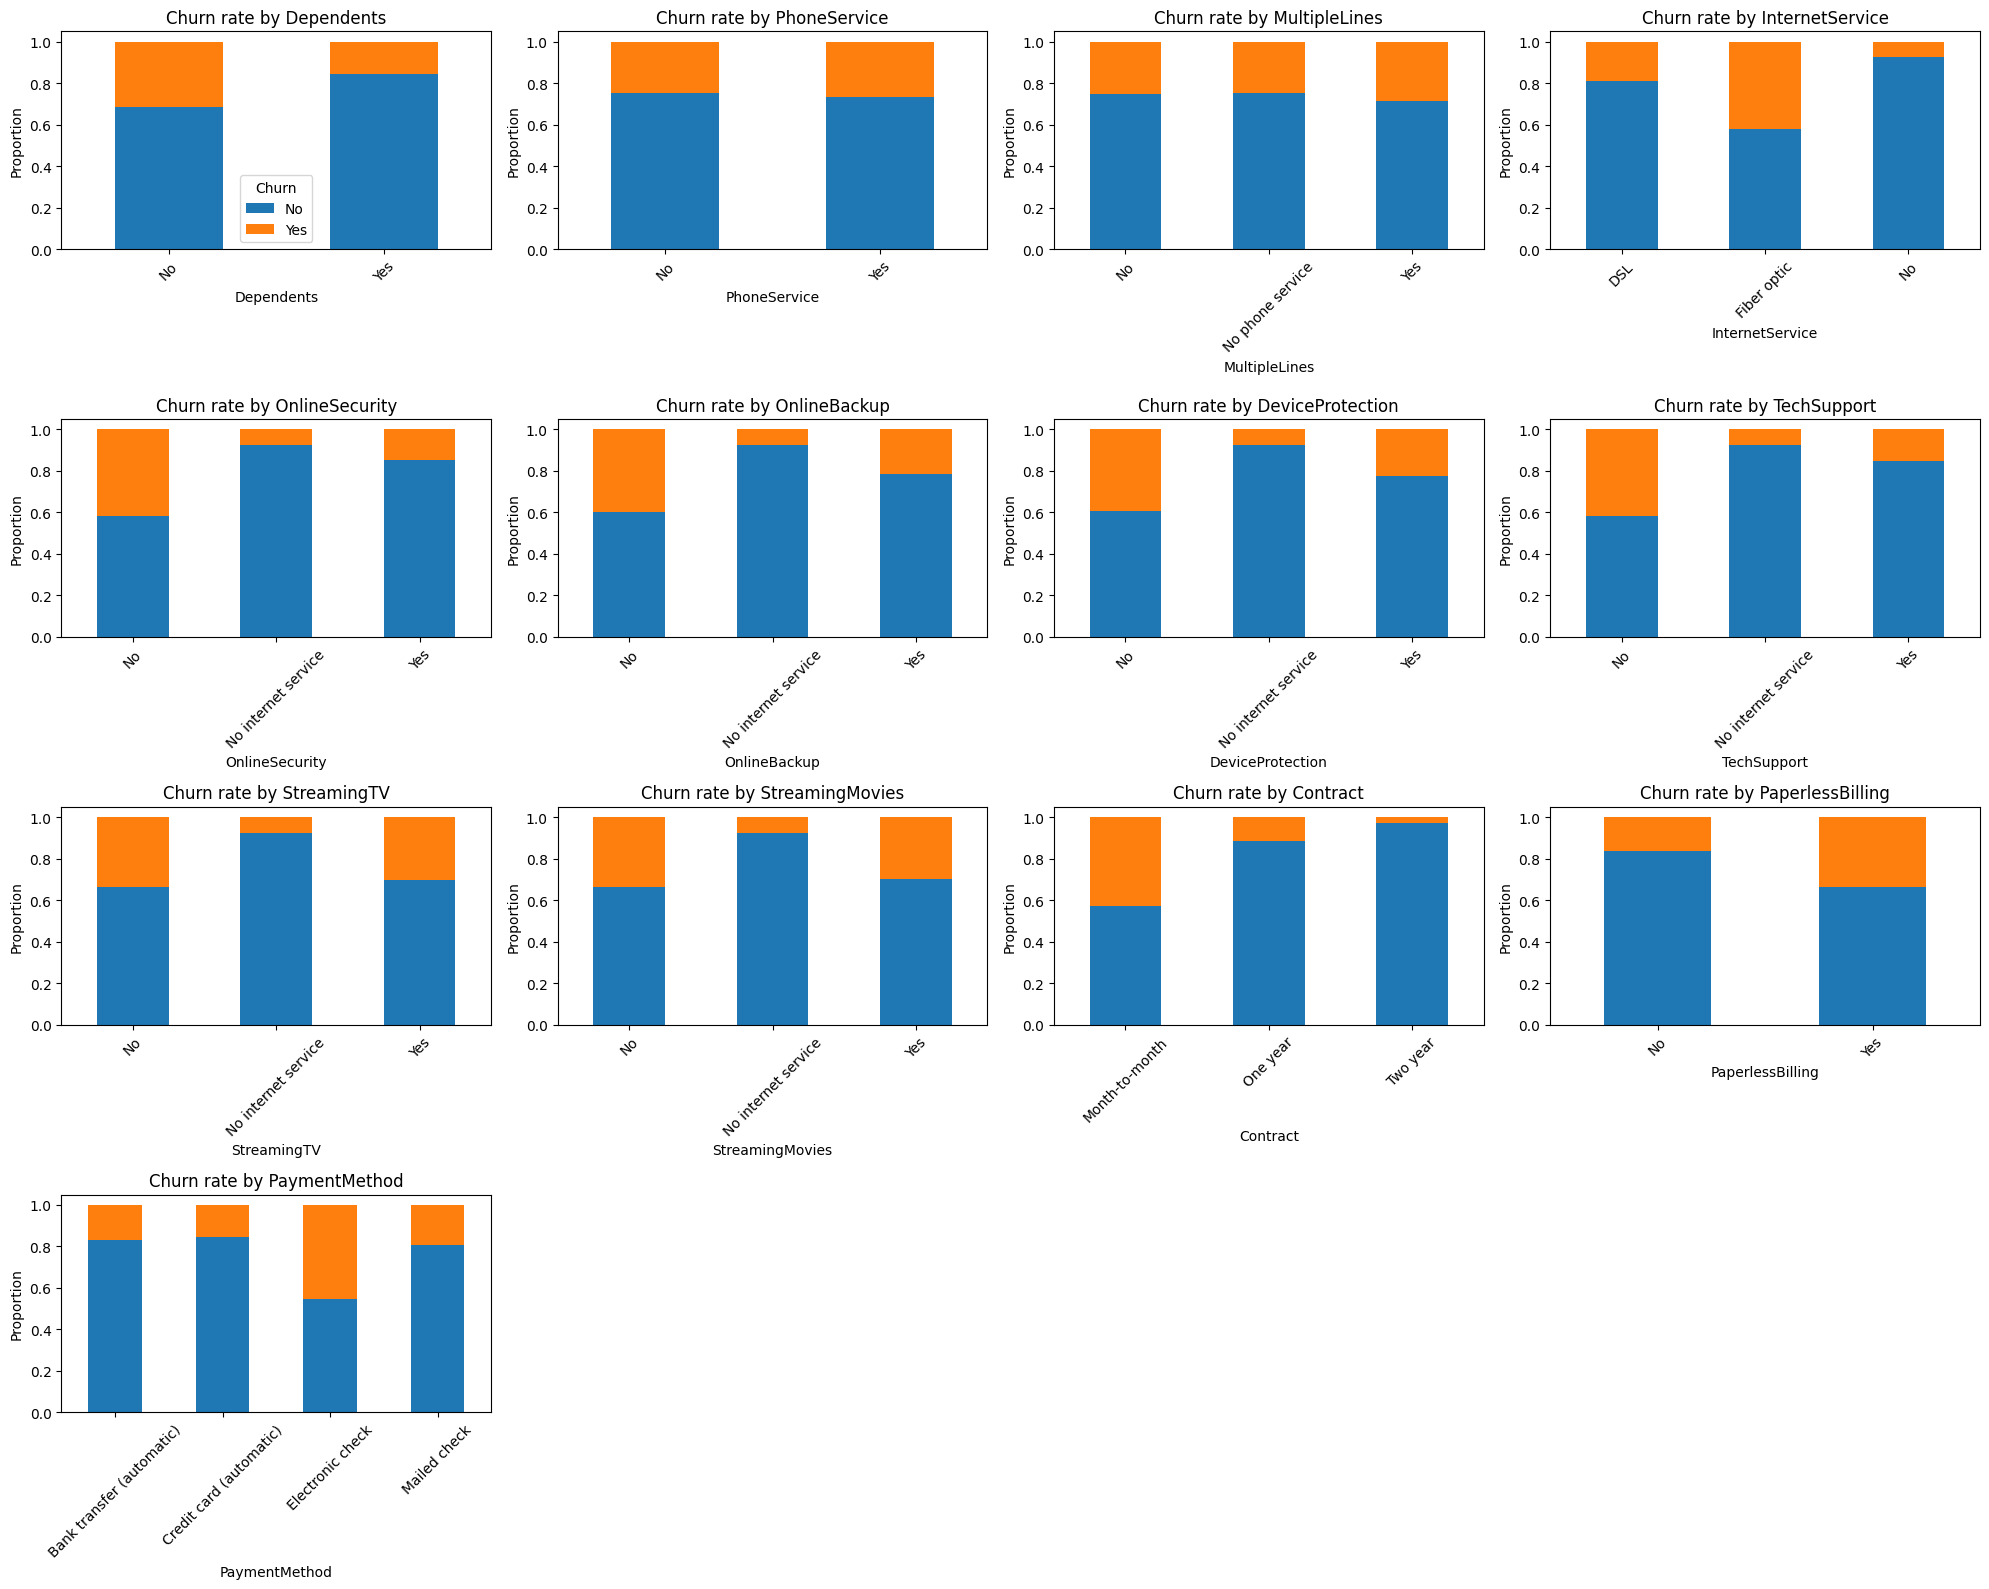

In [48]:
import matplotlib.pyplot as plt

exclude = ['customerID', 'gender', 'Partner', 'Churn', 'TotalCharges']
cat_cols = [c for c in churn.select_dtypes(include='object').columns if c not in exclude]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(churn[col], churn['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], legend=(i == 0))
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Top Features
- Contract, tenure, OnlineSecurity, TechSupport, InternetService, PaymentMethod

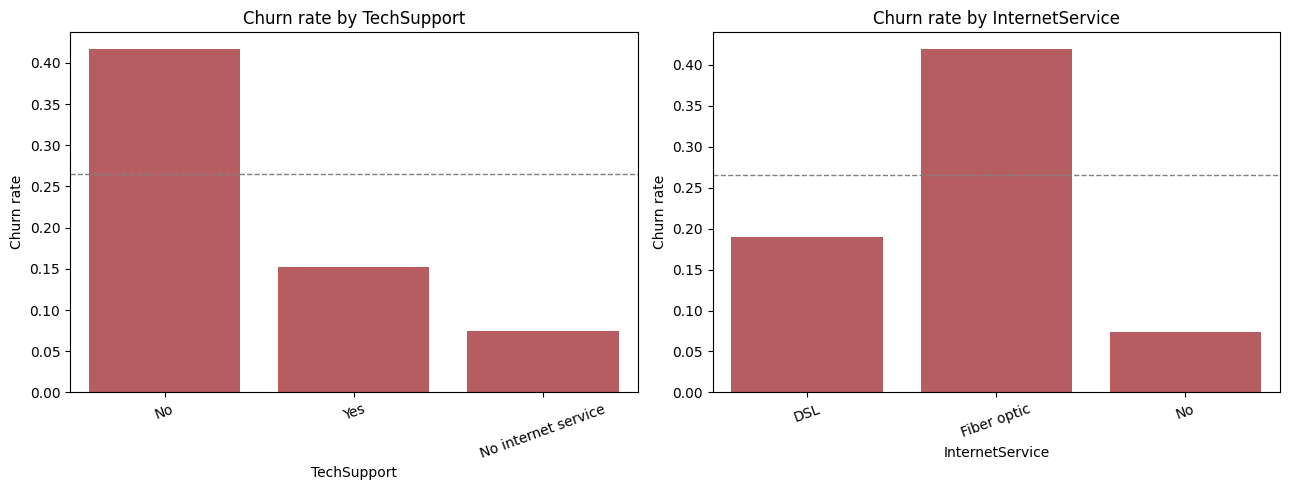

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

churn['Churn_binary'] = churn['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(1, 2, figsize=(13,5))

for i, col in enumerate(['TechSupport', 'InternetService']):
    sns.barplot(data=churn, x=col, y='Churn_binary', ax=axes[i], color='#c44e52', errorbar=None)
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate')
    axes[i].axhline(0.265, color='gray', linestyle='--', linewidth=1)
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

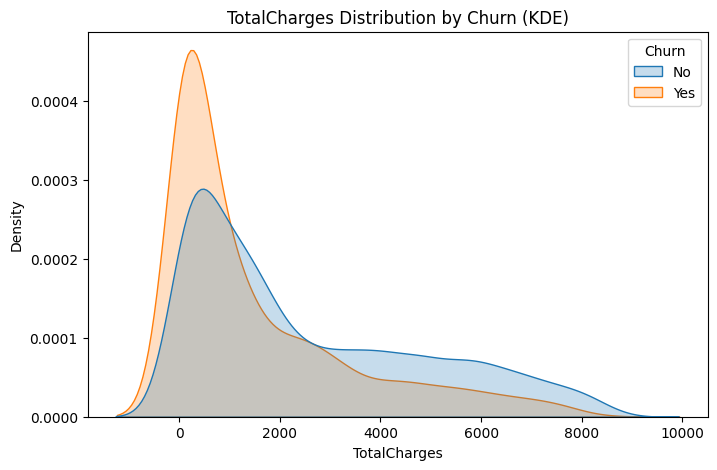

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(data=churn, x='TotalCharges', hue='Churn', fill=True, common_norm=False)
plt.title('TotalCharges Distribution by Churn (KDE)')
plt.show()

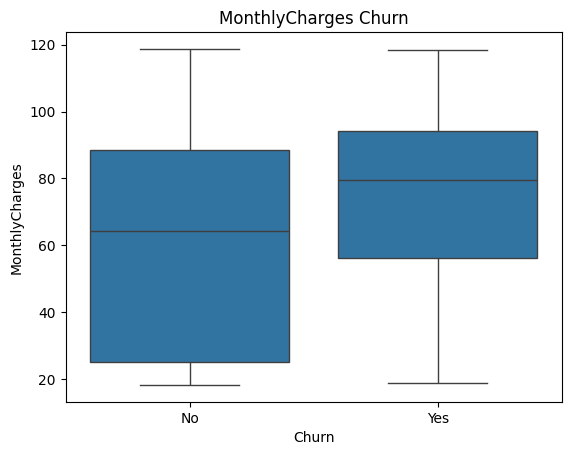

In [64]:
sns.boxplot(data=churn, x='Churn', y='MonthlyCharges')
plt.title('MonthlyCharges Churn')
plt.show()

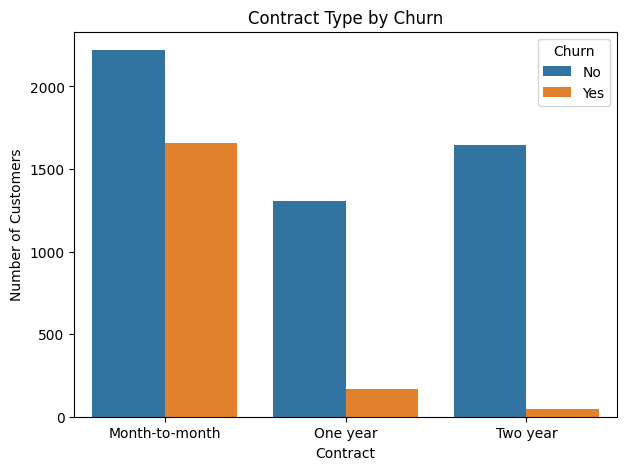

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Contract vs Churn
plt.figure(figsize=(7,5))
sns.countplot(data=churn, x='Contract', hue='Churn')
plt.title('Contract Type by Churn')
plt.ylabel('Number of Customers')
plt.show()

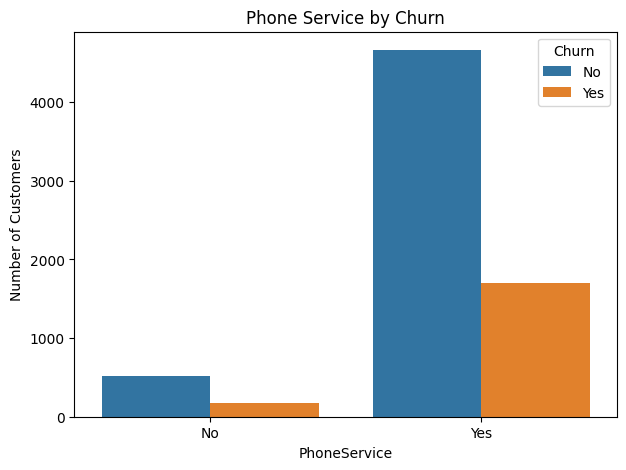

In [52]:
# PhoneService vs Churn
plt.figure(figsize=(7,5))
sns.countplot(data=churn, x='PhoneService', hue='Churn')
plt.title('Phone Service by Churn')
plt.ylabel('Number of Customers')
plt.show()

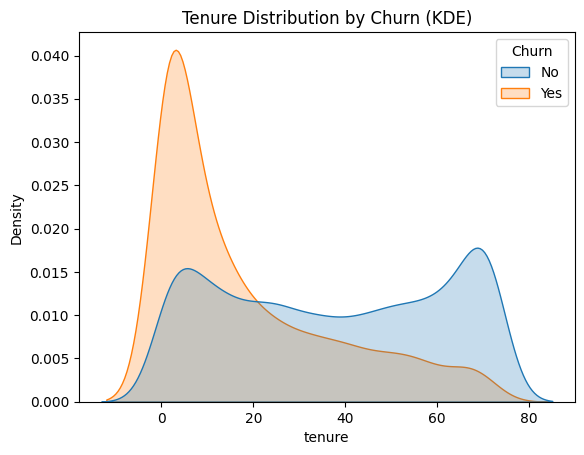

In [62]:
sns.kdeplot(data=churn, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.title('Tenure Distribution by Churn (KDE)')
plt.show()

# The Churn Rates by Combination of 2 or More Columns

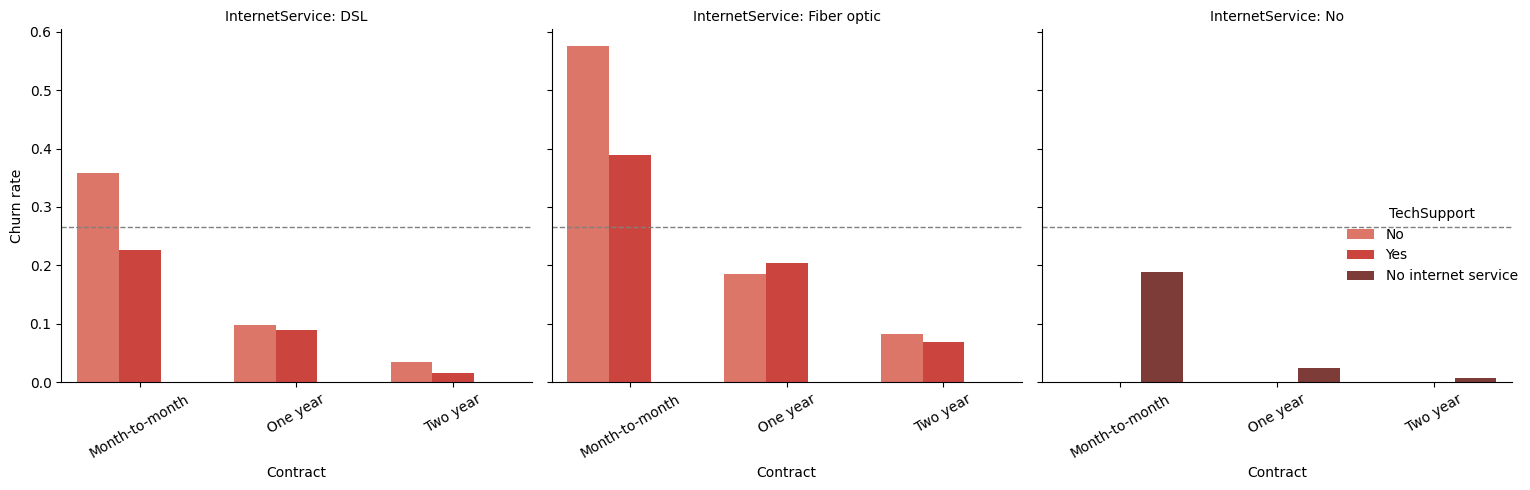

In [74]:
churn['Churn_binary'] = churn['Churn'].map({'Yes': 1, 'No': 0})

g = sns.catplot(
    data=churn, kind='bar',
    x='Contract', y='Churn_binary', hue='TechSupport', col='InternetService',
    errorbar=None, height=5, aspect=0.9, palette='Reds_d'
)
g.set_axis_labels('Contract', 'Churn rate')
g.set_titles('InternetService: {col_name}')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(0.265, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

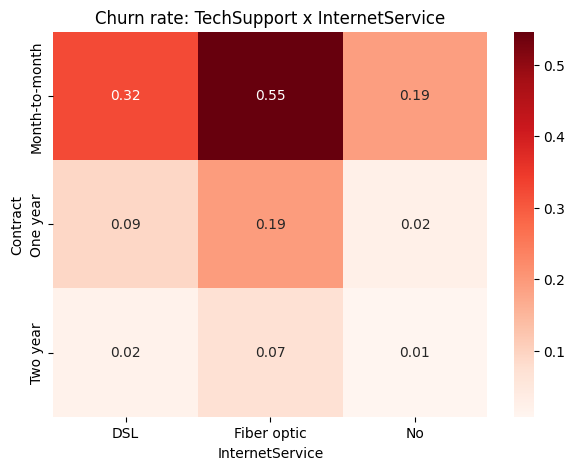

In [81]:
pivot = churn.pivot_table(index='Contract', columns='InternetService', values='Churn', aggfunc=lambda x: (x == 'Yes').mean())

plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds')
plt.title('Churn rate: TechSupport x InternetService')
plt.show()

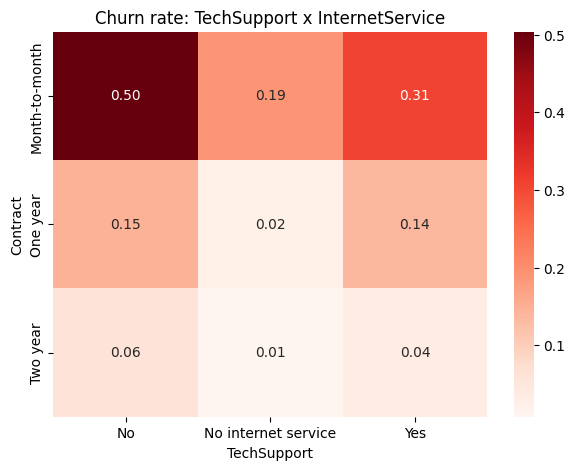

In [82]:
pivot = churn.pivot_table(index='Contract', columns='TechSupport', values='Churn', aggfunc=lambda x: (x == 'Yes').mean())

plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds')
plt.title('Churn rate: TechSupport x InternetService')
plt.show()